# 👩‍💻 Predicting House Prices Using Linear Regression

## 📋 Overview
In this hands-on lab, you'll work with the California Housing Dataset to build a linear regression model that predicts house prices. You’ll follow a real-world data science workflow: exploring the data, preparing it, training a model, and evaluating the results both quantitatively and visually.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- ✅ Load, explore, and prepare real-world tabular data
- ✅ Select features using correlation and EDA
- ✅ Train and evaluate a regression model
- ✅ Visualize and interpret model performance

## 📂 Task 1: Load the Dataset
**Context:** First, get the data into your environment so you can start exploring.

**Steps:**

- Use `fetch_california_housing(as_frame=True)` from sklearn.datasets.

- Access the DataFrame using the `.frame` attribute of the loaded object (e.g., `data = housing.frame`).

- Use `.head()`, `.info()`, and `.describe()` to inspect the structure and summary statistics.

**💡 Tip:** The target variable is 'MedHouseVal', which represents the median house value in $100,000s.

In [1]:
# Load the California housing dataset and display basic info

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load the dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame

print(data.shape)
# View data
data.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**⚙️ Test Your Work:**

- The DataFrame has 8 features and a 'MedHouseVal' column.

## 🔍 Task 2: Explore Data
**Context:** Get to know the data — see what features might relate to house prices.

**Steps:**

- Use histograms to inspect distributions.

- Use scatter plots to examine relationships (e.g., AveRooms vs. MedHouseVal).

- Use `seaborn.heatmap()` to check for correlations.

**Prompting Questions:**

- Which features have strong positive or negative correlation with price?

- Are any features skewed or have unusual patterns?

**💡 Tip:** Start with `sns.pairplot()` or `df.corr()` for quick insights.

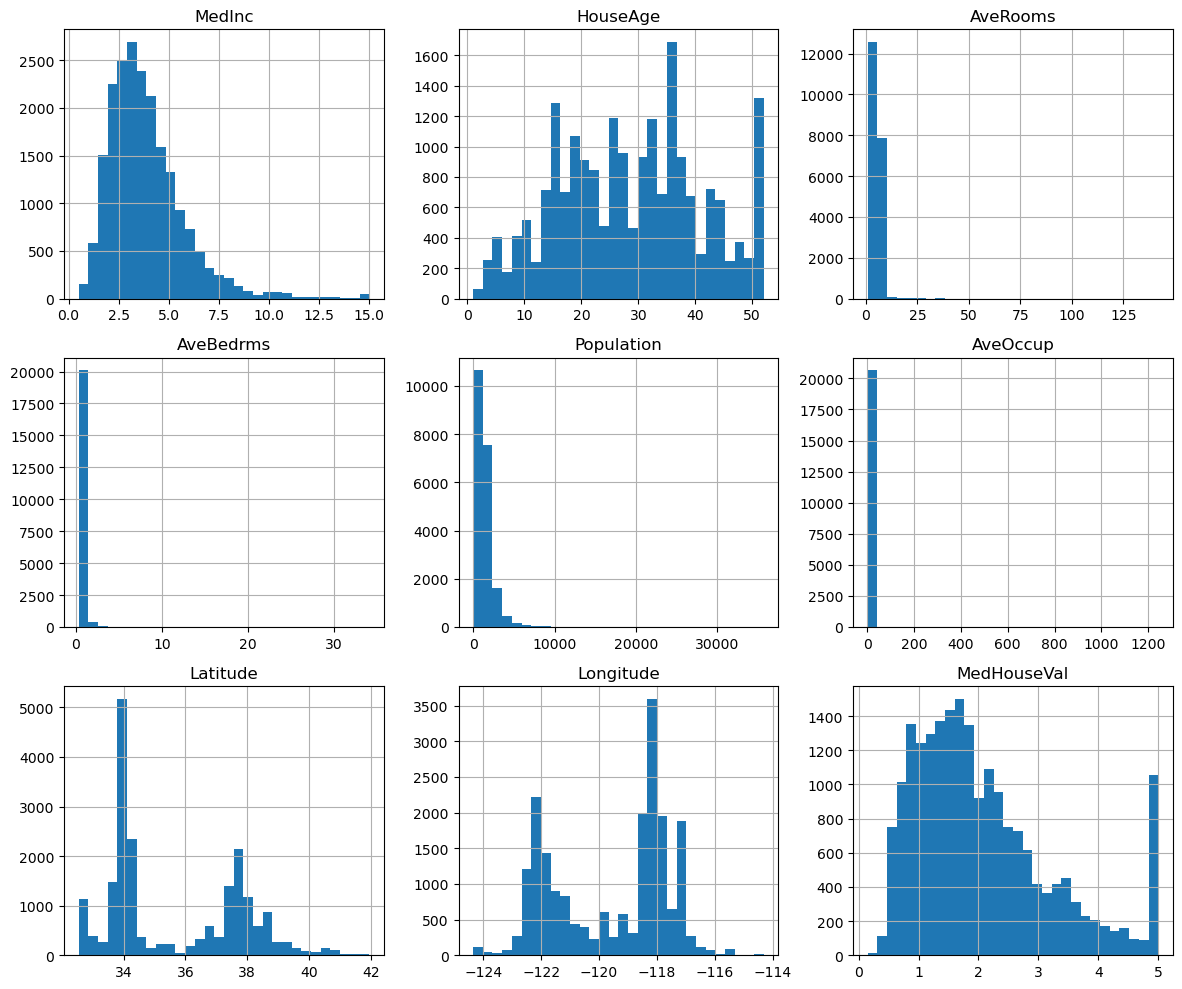

In [2]:
data.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

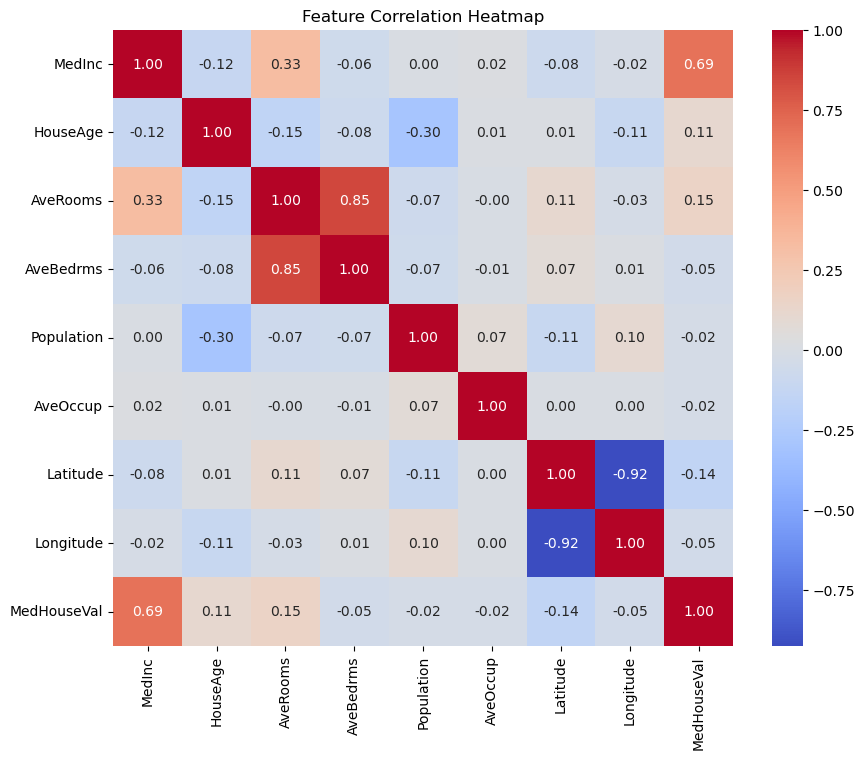

In [3]:
# Visualize correlations between features and house prices
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# sns.pairplot(data, hue='MedHouseVal')
# plt.show()

**⚙️ Test Your Work:**

- Correlation heatmap is generated

- Plots highlight a few key feature-price relationships

## 🧹 Task 3: Data Preparation
**Context:** Clean and prepare data to ensure the model trains effectively.

**Steps:**

- Check for missing values and handle if needed (e.g., `.isnull().sum()`).

- Standardize or normalize numeric features using StandardScaler (optional for linear regression but good practice).

- Drop or transform any problematic columns if identified in EDA.

**💡 Tip:** Standardizing features helps models converge faster and compare weights meaningfully.

In [5]:
# Clean and prepare the dataset
missing_summary = data.isnull().sum()
print("Missing values per column:\n", missing_summary)

Missing values per column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
# Select numeric columns (excluding target if needed)
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('MedHouseVal')

scaler = StandardScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

**⚙️ Test Your Work:**
- No missing values remain
- Feature scales are consistent (if standardized)

## 🧠 Task 4: Feature Selection
**Context:** Choose the most relevant features for the model using your EDA.

**Steps:**

- Use correlation coefficients (`.corr()`) to identify strong predictors.

- Drop weak or redundant features (e.g., highly correlated pairs).

- Store selected features in a new variable `X_selected`.

**Prompting Questions:**

- Are any features too weakly correlated to be useful?

- Are any features too correlated with each other?

**💡 Tip:** Remove multicollinear features to avoid redundant information.

In [8]:
# Select features with highest correlation to target
correlation_matrix = data.corr()
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal')
print(target_corr.sort_values(ascending=False))

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [11]:
strong_features = target_corr[abs(target_corr) > 0.1].index.tolist()
strong_features

['MedInc', 'HouseAge', 'AveRooms', 'Latitude']

In [14]:
# Check inter-feature correlations
inter_corr = data[strong_features].corr().abs()

# Drop one of each highly correlated pair (e.g., > 0.8)
upper_triangle = inter_corr.where(np.triu(np.ones(inter_corr.shape), k=1).astype(bool))

redundant_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]
selected_features = [f for f in strong_features if f not in redundant_features]
X_selected = data[selected_features]

**⚙️ Test Your Work:**
- X_selected contains the cleaned and selected features

## 🧪 Task 5: Train the Model
**Context:** Now you’ll train a simple linear regression model using your selected features.

**Steps:**

- Split the data using `train_test_split()`

- Instantiate `LinearRegression()` from scikit-learn

- Fit the model using `model.fit(X_train, y_train)`

In [16]:
# Train a linear regression model on the selected features
X = X_selected
y = data['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.8326685457491143
Intercept: 2.068703728832835


**⚙️ Test Your Work:**

- Model trains without error

- Coefficients and intercept are available with `.coef_` and `.intercept_`

## 📈 Task 6: Model Evaluation
**Context:** Time to see how well your model actually performs.

**Steps:**

- Predict prices on the test set

- Use `r2_score()` and `mean_squared_error()` to evaluate

- Print and interpret the results

**💡 Tip:** R² tells you how much variance is explained by the model. MSE shows average squared error.

In [17]:
# Evaluate model with R2 and MSE
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R² Score: 0.5043
Mean Squared Error: 0.6495


**⚙️ Test Your Work:**
- R² and MSE values are printed and interpreted
- Reasonable performance based on initial expectations

## 📊 Task 7: Visualize Results
**Context:** Visual validation helps you see model strengths and weaknesses.

**Steps:**

- Create a scatter plot of y_test vs. y_pred

- Plot a diagonal reference line

- Optionally: Create a residual plot to examine prediction errors

**Prompting Questions:**

- Are predictions close to actuals?

- Is there a pattern in residuals?

**💡 Tip:** A good model will have points close to the diagonal line in actual vs predicted plots.

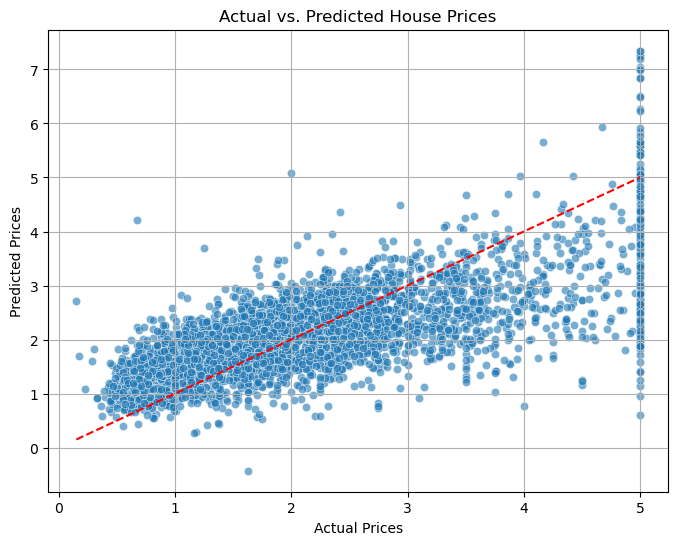

In [18]:
# Plot actual vs predicted prices and residuals

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # reference line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted House Prices')
plt.grid(True)
plt.show()


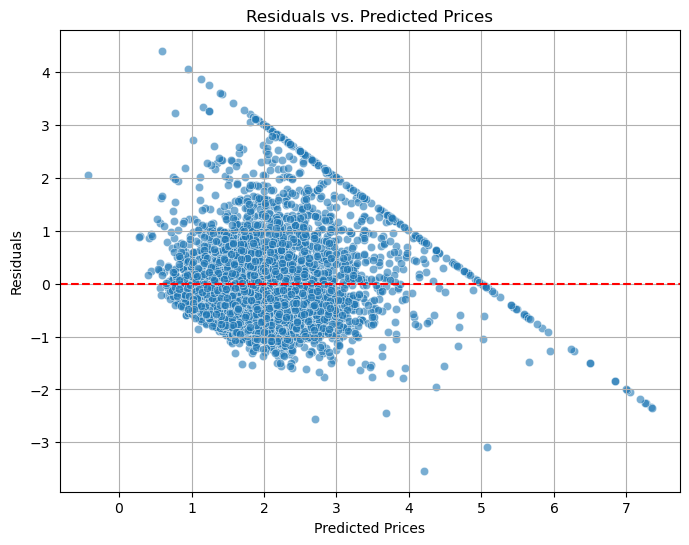

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Prices')
plt.grid(True)
plt.show()

**⚙️ Test Your Work:**

- Scatter plot clearly shows prediction alignment

- Residual plot doesn’t show major systematic error

## ✅ Success Checklist
- Dataset loaded into DataFrame

- EDA completed with meaningful plots

- Features cleaned and optionally standardized

- Top features selected based on correlation

- Model trained and evaluated

- Visualizations of predictions created

## 🔑 Key Points
- EDA is critical for understanding and preparing data

- Feature selection improves model performance and interpretability

- R-squared and MSE are key metrics for regression accuracy

## Exemplar Solution

After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches. 

Reflect on what you can learn from the exemplar solution to improve your coding skills.

Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.

Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>
    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>    

```python
# 📦 Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 📂 Load the dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame

# 🔍 Explore the data
print(data.info())
print(data.describe())

# Plot histogram of target
plt.hist(data['MedHouseVal'], bins=30, edgecolor='k')
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Frequency")
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# 🧹 Data preparation
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 🧠 Feature selection (based on correlation heatmap)
selected_features = ['MedInc', 'AveRooms', 'HouseAge']
X_selected = X_scaled[selected_features]

# 🧪 Split the data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# 📈 Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔮 Predict
y_pred = model.predict(X_test)

# 🧮 Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# 📊 Visualize predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs. Predicted House Values")
plt.grid(True)
plt.show()
```